## Traverse field Ising model to demo primitives

In [6]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import YGate,UnitaryGate
import numpy as np

SYGate =UnitaryGate(YGate().power(1/2), label=r'$\sqrt{Y}$')
SYdgGate =UnitaryGate(SYGate.inverse() , label=r'$\sqrt{Y}^\dag$')

In [7]:
def generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, trotter_barrier=False, layer_barrier=False):
    qc = QuantumCircuit(num_qubits)

    for trotter_step in range(num_trotter_steps):
        add_id_tfim_trotter_layer(qc,rx_angle, layer_barrier)
        if trotter_barrier:
            qc.barrier()

    return qc
    
def add_id_tfim_trotter_layer(qc, rx_angle, layer_barrier = False):
     #Adding Rzz in even layers
     for i in range(0, qc.num_qubits - 1, 2):  
         qc.sdg([i, i + 1])
         qc.append(SYGate, [i+1])
         qc.cx(i, i + 1)
         qc.append(SYdgGate, [i + 1])
     if layer_barrier:
         qc.barrier()
     #Adding Rzz in odd layers
     for i in range(1, qc.num_qubits - 1, 2):  
         qc.sdg([i, i + 1])
         qc.append(SYGate, [i+1])
         qc.cx(i, i + 1)
         qc.append(SYdgGate, [i + 1])
     if layer_barrier:
         qc.barrier()
     qc.rx(rx_angle, list(range(qc.num_qubits)))
     if layer_barrier:
        qc.barrier()

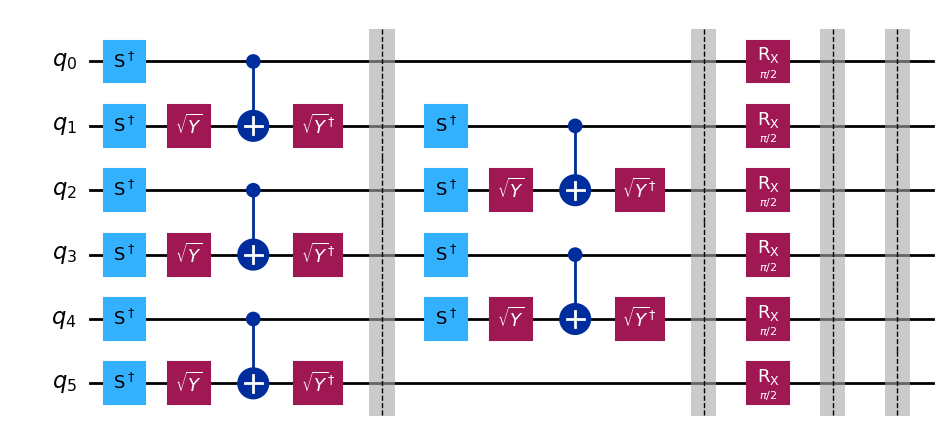

In [8]:
num_qubits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, trotter_barrier=True, layer_barrier=True)
qc.draw('mpl', fold=-1)

## Demo Sampler

In [9]:
def append_mirrored_1d_tfim_circuit(qc,num_qubits, num_trotter_steps, rx_angle, trotter_barrier=False, layer_barrier=False):

    for trotter_step in range(num_trotter_steps):
        add_mirrored_id_tfim_trotter_layer(qc,rx_angle, layer_barrier)
        if trotter_barrier:
            qc.barrier()

    return qc
    
def add_mirrored_id_tfim_trotter_layer(qc, rx_angle, layer_barrier = False):
     qc.rx(-rx_angle, list(range(qc.num_qubits)))
     if layer_barrier:
        qc.barrier()
     #Adding Rzz in odd layers
     for i in range(1, qc.num_qubits - 1, 2):  
         qc.append(SYGate, [i+1])
         qc.cx(i, i + 1)
         qc.append(SYdgGate, [i + 1])
         qc.s([i, i + 1]) 
     if layer_barrier:
         qc.barrier()   
     #Adding Rzz in even layers
     for i in range(0, qc.num_qubits - 1, 2):  
         qc.append(SYGate, [i+1])
         qc.cx(i, i + 1)
         qc.append(SYdgGate, [i + 1])
         qc.s([i, i + 1])
     if layer_barrier:
         qc.barrier()

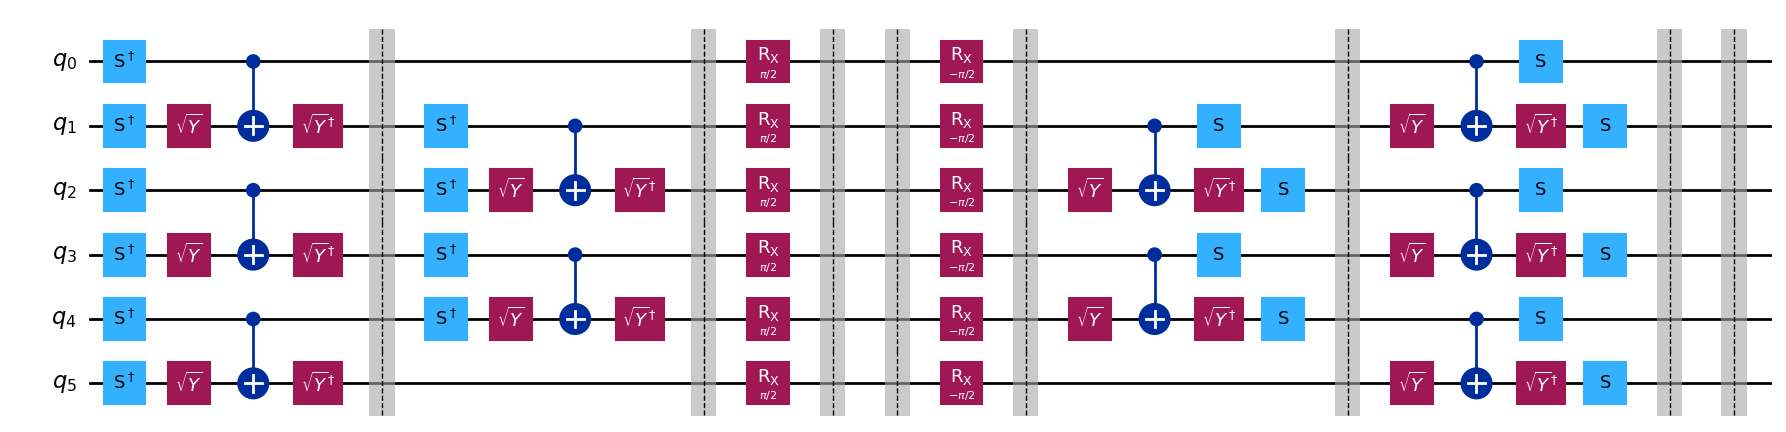

In [10]:
append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barrier=True, layer_barrier=True)
qc.draw('mpl', fold=-1)